In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
class cpc_data_simulator():
    def __init__(self, n_sources, groups_of_dep_var, n_states, sigma, fs, length):
        self.n_sources = n_sources if isinstance(n_sources, list) else groups_of_dep_var*[n_sources]
        self.groups_of_dep_var = groups_of_dep_var
        self.sigma = sigma
        self.fs = fs
        self.length = length
        self.n_settings = n_states
        self.source_frequencies = np.zeros((n_states, np.sum(n_sources)))
        self.emission_matrix = np.zeros((np.sum(groups_of_dep_var), np.sum(n_sources)))
        k = 0
        j = 0
        for source, group in zip(n_sources, groups_of_dep_var):
            self.emission_matrix[j:j+group, k:k+source] = np.random.normal(0, 1, (group, source))
            self.source_frequencies[:, k:k+source] = np.random.uniform(1, 50, (n_states, source))
            j+=group
            k+=source
    
    def generate(self, n_samples, return_sources = False, shuffle_variables = True):
        # Generate the independent variables
        t = np.repeat(np.expand_dims(np.arange(0, self.length, 1/self.fs), axis = 0), n_samples, axis = 0)
        # Generate a random phase shift per sample
        phase_shift = np.expand_dims(np.random.uniform(0, 2*np.pi, n_samples), 1)
        # Generate the dependent variables
        y = np.zeros((n_samples, round(self.length*self.fs) , np.sum(self.groups_of_dep_var)))
        states = np.random.randint(0, self.n_settings, n_samples)

        if return_sources:
            sources = np.zeros((n_samples, round(self.length*self.fs), np.sum(self.n_sources)))

        for k in range(np.sum(self.n_sources)):
            y += np.expand_dims(np.sin(np.expand_dims(self.source_frequencies[states, k],1) * t + phase_shift), 2) @ np.expand_dims(self.emission_matrix[:, k], 0)
            if return_sources:
                sources[:, :, k] = np.sin(np.expand_dims(self.source_frequencies[states, k],1) * t + phase_shift)

        # Add noise
        y += np.random.normal(0, self.sigma, (n_samples, round(self.length*self.fs), np.sum(self.groups_of_dep_var)))
        # randomly shuffle the variables
        idx = np.arange(np.sum(self.groups_of_dep_var))
        np.random.shuffle(idx)
        if return_sources:
            if shuffle_variables:
                return y[:, :, idx], sources, self.emission_matrix[:, idx]
            return y, sources, self.emission_matrix
        else:
            return y[:, :, idx]

In [16]:
class multiview_data_simulator():
    def __init__(self, n_sources, n_variables, n_states, sigma, fs, length):
        self.n_sources = n_sources 
        self.n_variables = n_variables
        self.sigma = sigma
        self.fs = fs
        self.length = length
        self.n_settings = n_states
        self.source_frequencies = np.random.uniform(1, 50, (n_states, n_sources))
        self.emission_matrix = np.random.normal(0, 1, (n_sources, n_variables))
    
    def generate(self, n_samples, return_sources = False):
        # Generate the independent variables
        t = np.expand_dims(np.arange(0, self.length/2, 1/self.fs),0)
        t_len = t.shape[1]
        # Generate a random phase shift per sample
        phase_shift = np.expand_dims(np.random.uniform(0, 2*np.pi, n_samples), 1)
        # Generate the dependent variables
        y = np.zeros((n_samples, t_len*2, self.n_variables))

        if return_sources:
            sources = np.zeros((n_samples, round(self.length*self.fs), np.sum(self.n_sources)))

        for n in range(n_samples):
            states = np.random.choice(np.arange(0, self.n_settings), 2, replace = False)
            y[n,:t_len,:] = np.sin(np.expand_dims(self.source_frequencies[states[0]],1) * t + phase_shift[n]).T @ self.emission_matrix
            y[n,t_len:,:] = np.sin(np.expand_dims(self.source_frequencies[states[1]],1) * t + phase_shift[n]).T @ self.emission_matrix
            if return_sources:
                sources[n,:t_len,:]= np.sin(np.expand_dims(self.source_frequencies[states[0]],1) * t + phase_shift[n]).T
                sources[n,t_len:,:]= np.sin(np.expand_dims(self.source_frequencies[states[1]],1) * t + phase_shift[n]).T

        # Add noise
        y += np.random.normal(0, self.sigma, (n_samples, round(self.length*self.fs), self.n_variables))

        if return_sources:
            return y, sources, self.emission_matrix
        else:
            return y

In [27]:
n_var = 10
n_sources = 5
datagenerator = multiview_data_simulator(n_sources, n_var, 20, 0.5, 1000, 1)

data, sources, emission_matrices = datagenerator.generate(1000, return_sources = True)

In [28]:
n_var = 8
n_sources = 5
datagenerator = cpc_data_simulator([2,3], [n_var, 2], 20, 0.5, 1000, 1)

cpc_data, cpc_sources, cpc_emission_matrices = datagenerator.generate(1000, return_sources = True, shuffle_variables=False)

In [29]:
n_points_to_plot = 1
data_to_plot = np.random.choice(data.shape[0], n_points_to_plot, replace = False)

In [30]:
def plot_data(data, sources, emission_matrices, data_to_plot):
    data_sources, vars, titles = [data, emission_matrices, sources], [data.shape[2], 1, sources.shape[2]], ['Data', 'Mixing matrix', 'Sources']

    fig = plt.figure(figsize=(15, n_points_to_plot*5))
    subfigs = fig.subfigures(len(data_to_plot), 1, squeeze=False)

    for k in range(len(data_to_plot)):
        subfig_ax = subfigs[k][0].subfigures(1, 3)
        for i in range(3):
            ax = subfig_ax[i].subplots(vars[i], 1, squeeze=False)
            subfig_ax[i].suptitle('{}'.format(titles[i]))
            if i == 1:
                pos = ax[0][0].imshow(data_sources[i], aspect = 'auto')
                fig.colorbar(pos, ax=ax[0][0])
                continue
            for j in range(vars[i]):
                ax[j][0].plot(data_sources[i][data_to_plot[k], :, j])
                # put vertical line at the middel of the time axis
                ax[j][0].axvline(x=data_sources[i].shape[1]/2, color='r', linestyle='--')
    plt.tight_layout()
    plt.show()

/var/folders/xl/fct1_y7d2tn5g3_7qcd7m89h0000gn/T/ipykernel_86382/4219362126.py:20: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


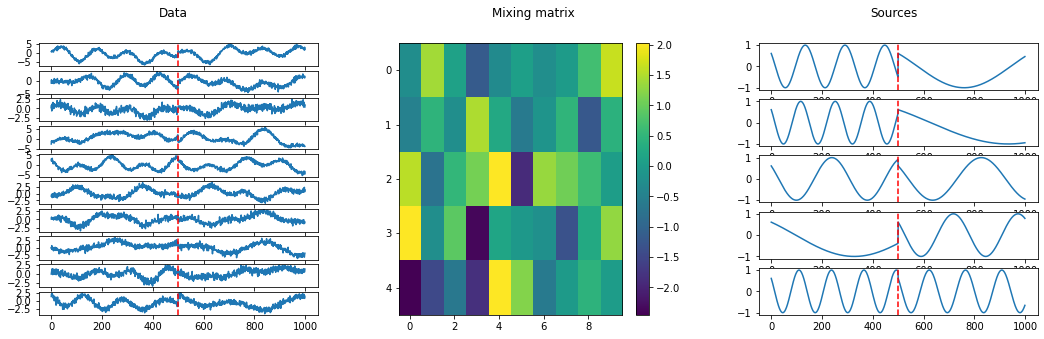

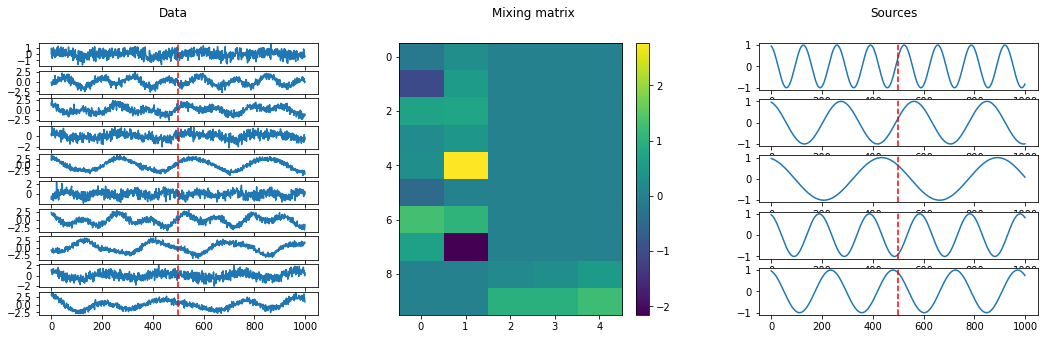

In [31]:
plot_data(data, sources, emission_matrices, data_to_plot)
plot_data(cpc_data, cpc_sources, cpc_emission_matrices, data_to_plot)

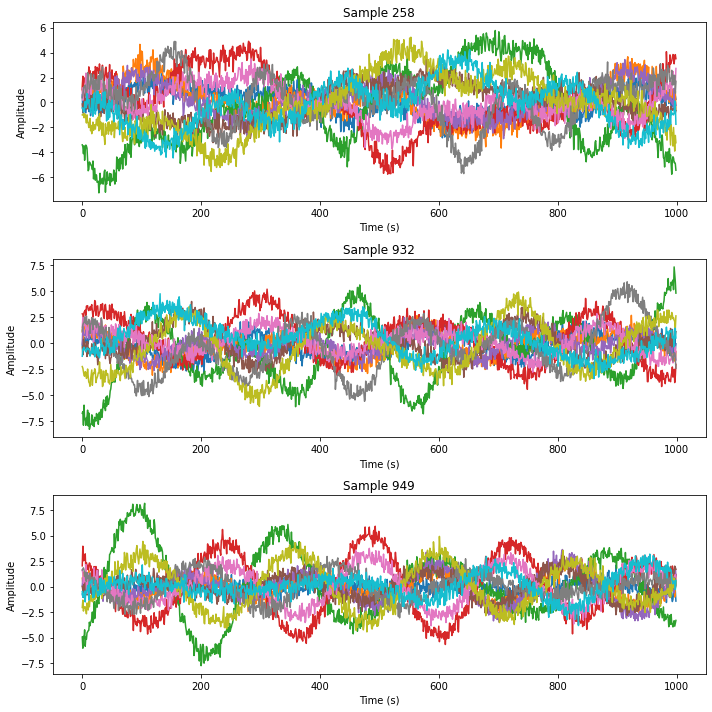

In [11]:
n_points_to_plot = 3
data_to_plot = np.random.choice(data.shape[0], n_points_to_plot, replace = False)

fig, ax = plt.subplots(n_points_to_plot, 1, figsize = (10, 10))

for k in range(n_points_to_plot):
    ax[k].plot(data[data_to_plot[k], :, :])
    ax[k].set_title('Sample {}'.format(data_to_plot[k]))
    ax[k].set_xlabel('Time (s)')
    ax[k].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()